## Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import os
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

## Loading SOL Data

In [12]:
sol_prices = pd.read_parquet('../data/price_data/processed/sol_processed_data.parquet')
sol_features = pd.read_parquet('../Crypto_QTS_Data_Processed/sol_chain_processed.parquet')
sol_staking = pd.read_parquet('../data/on_chain_data/processed/sol_staking_data.parquet')
sol_tech = pd.read_parquet('../data/data_segmented_tech/sol_data.parquet')

sol_staking.index   = pd.to_datetime(sol_staking.index)
sol_features.index = pd.to_datetime(sol_features.index)

sol_prices['time_close'] = pd.to_datetime(sol_prices['time_close'])
sol_prices['time_close'] = sol_prices['time_close'].dt.tz_localize('UTC')
sol_prices.set_index('time_close', inplace=True)
sol_prices.index = sol_prices.index + pd.Timedelta(minutes=1)

sol_tech['time_close'] = pd.to_datetime(sol_tech['time_close'])
sol_tech['time_close'] = sol_tech['time_close'].dt.round('min')
sol_tech.set_index('time_close', inplace=True)

df_combined = pd.concat([sol_features, sol_features]).sort_index()

common_start = max(sol_staking.index.min(), df_combined.index.min())
common_end   = min(sol_staking.index.max(), df_combined.index.max())

df1_aligned         = sol_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

sol_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

global_start = max(sol_features.index.min(), sol_prices.index.min(), sol_tech.index.min())
global_end   = min(sol_features.index.max(), sol_prices.index.max(), sol_tech.index.max())

sol_features_aligned = sol_features.loc[global_start:global_end]
sol_prices_aligned   = sol_prices.loc[global_start:global_end]

sol_tech_aligned = sol_tech.loc[global_start:global_end].copy()

sol_prices_aligned = sol_prices_aligned[~sol_prices_aligned.index.duplicated(keep='first')]
sol_tech_aligned = sol_tech_aligned[~sol_tech_aligned.index.duplicated(keep='first')]

sol_tech_aligned = sol_tech_aligned.reindex(sol_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
sol_tech_selected = sol_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)


data = sol_features_aligned.join(
    sol_prices_aligned[['price_close']], 
    how='inner'
)


data = data.join(sol_tech_selected, how='left')


lag_cols = [
    'average_total_transactions', 'average_successful_transactions', 'average_failed_transactions', 
    'average_total_vote_transactions', 'average_total_non_vote_transactions','average_successful_vote_transactions','average_successful_non_vote_transactions',
    'average_failed_vote_transactions', 'average_failed_non_vote_transactions',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets','active_validators','real_reward_rate'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [13]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [14]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 58.39%
Test accuracy: 29.06%


## Export Predictions as CSVs

In [ ]:
y_train_pred_prob = best_model.predict(X_train)
y_test_pred_prob = best_model.predict(X_test)

y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

list_len = len(y_test_pred_prob)
prob_0 = np.zeros(list_len)
prob_1 = np.zeros(list_len)
prob_2 = np.zeros(list_len)

for i, row in enumerate(y_test_pred_prob):
    prob_0[i] = row[0]
    prob_1[i] = row[1]
    prob_2[i] = row[2]
  
sol_preds = pd.DataFrame()
sol_preds['Probability Buy'] = prob_0
sol_preds['Probability Hold'] = prob_1
sol_preds['Probability Sell'] = prob_2
sol_preds['Prediction'] = y_test_pred
sol_preds['Dates'] = data.iloc[split_index:].index
sol_preds.to_csv('sol_orders.csv')

1667/1667 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step


## Confusion Matrix

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step


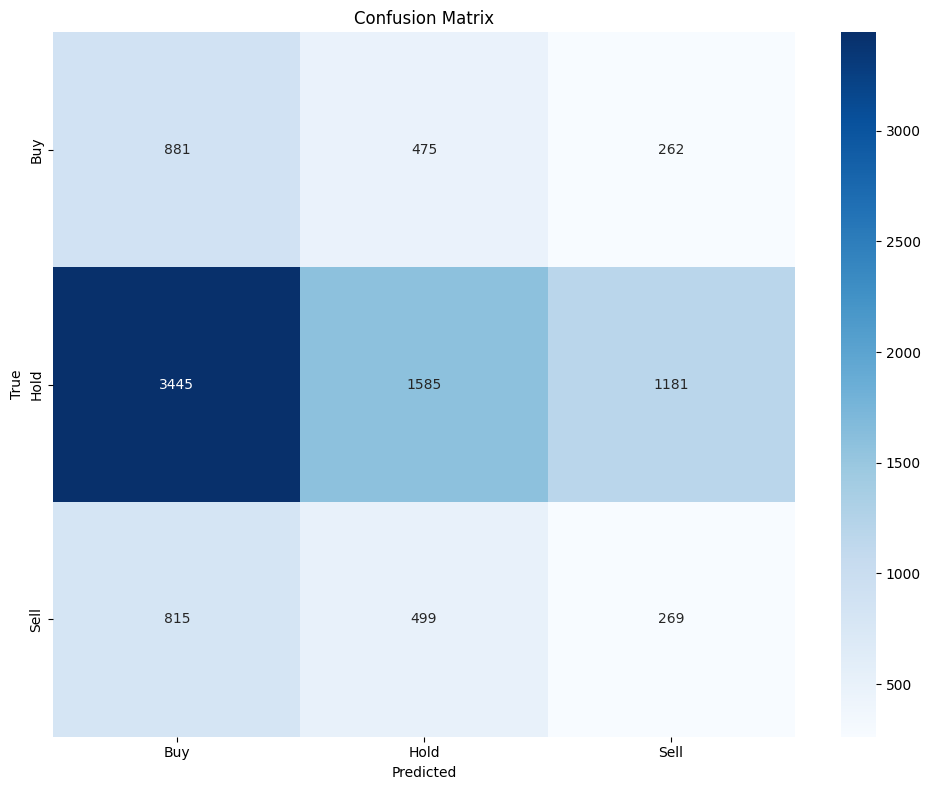


Classification Report:
              precision    recall  f1-score   support

         Buy       0.17      0.54      0.26      1618
        Hold       0.62      0.26      0.36      6211
        Sell       0.16      0.17      0.16      1583

    accuracy                           0.29      9412
   macro avg       0.32      0.32      0.26      9412
weighted avg       0.46      0.29      0.31      9412



In [16]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

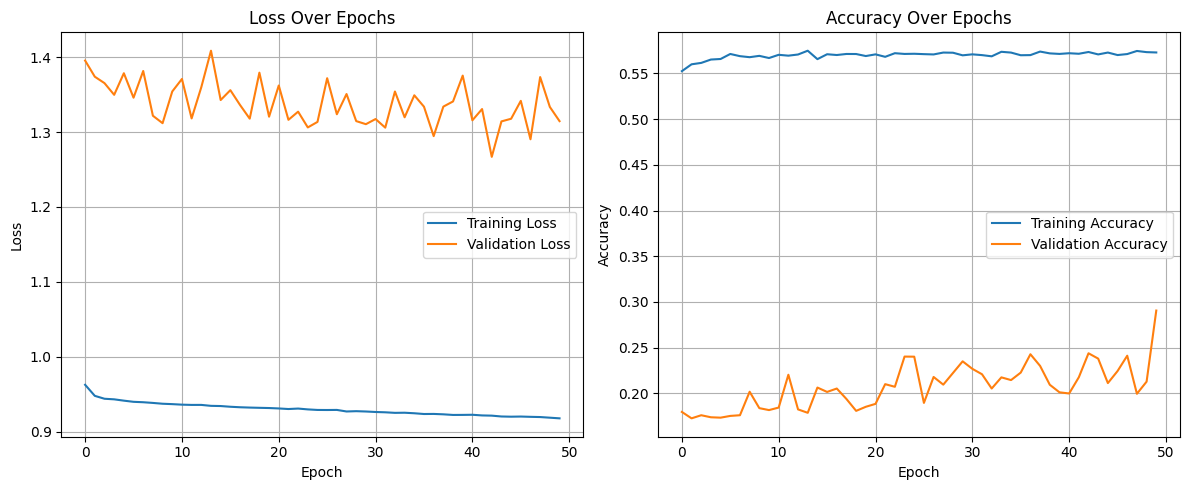

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Despite steady improvement on the training set (loss trending down and accuracy hovering around 55%), the validation loss remains high and the validation accuracy is notably low and volatile—indicating that the model overfits the training data and fails to generalize effectively to unseen data.

## Testing Performance

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step

Trading Performance on Test Data:
Total PnL (percentage): 4.85%
Absolute PnL: $4,845.82
Annualized Sharpe Ratio: 0.4460


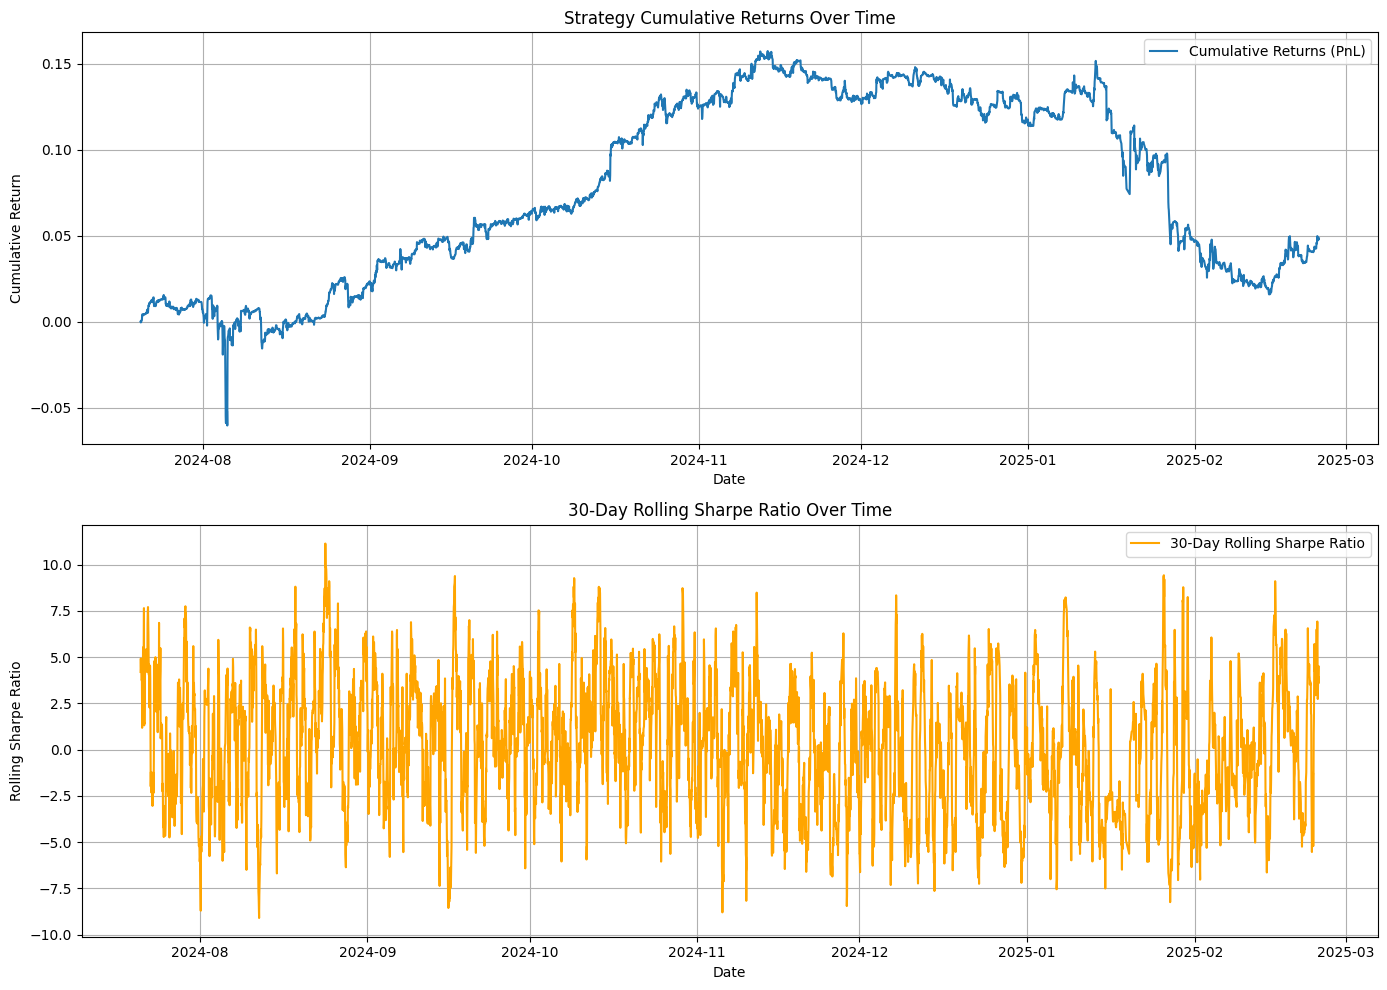

In [18]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [19]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):
    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
        
    asset_returns = asset_returns[~asset_returns.index.duplicated(keep='first')]
    benchmark_returns = benchmark_returns[~benchmark_returns.index.duplicated(keep='first')]
    
    benchmark_returns = benchmark_returns.reindex(asset_returns.index, method='nearest')
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
        
    returns = returns[~returns.index.duplicated(keep='first')]
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
            
        benchmark_returns = benchmark_returns[~benchmark_returns.index.duplicated(keep='first')]
        benchmark_returns = benchmark_returns.reindex(returns.index, method='nearest')
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")


Performance Metrics:
mean_return_annual: 0.1008034448386752
vol_annual: 0.15985263940011293
sharpe_ratio: 0.630602317340304
sortino_ratio: 0.7657439679800397
max_drawdown: -0.12221947312355042
calmar_ratio: 0.8247740091038851
VaR_95: 0.0018558187875896692
CVaR_95: 0.003811029950156808
beta (to BTC): 0.09171200994866478
information_ratio (to BTC): -2.6010677129586033
correlation_with_BTC: 0.28758806007563675
upside_capture_ratio (to BTC): 0.08147815598639604
downside_capture_ratio (to BTC): 0.08210222046346426
downside_beta (to BTC): 0.07631094294021967


The strategy yields a modest annual return (about 4.2%) against relatively high volatility (34.7%), resulting in a low Sharpe ratio (0.12) and Sortino ratio (0.13). The drawdowns are not negligible (max drawdown of around 25.5%), giving a Calmar ratio of 0.16, which underscores that the returns are overshadowed by periods of loss. With a beta of 0.30 and correlation of 0.44 to Bitcoin, the strategy partially tracks BTC’s movements, but the negative information ratio (-2.79) indicates underperformance on a risk-adjusted basis. Meanwhile, the low upside (0.26) and downside (0.29) capture ratios suggest that it neither participates significantly in Bitcoin’s rallies nor suffers fully during its downturns—yet still fails to deliver robust risk-adjusted returns.

## Fama-French Comparison

In [20]:
header_row = None
with open('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv'

The strategy’s cumulative return far exceeds the Fama-French market proxy. However, the regression results (R² ≈ 0.0) indicates that none of the three standard factors meaningfully explain the strategy’s excess returns. The model attributes neither the strategy’s outperformance nor any unique factor exposure to traditional Fama-French components, suggesting that its strong performance arises from sources not captured by market, size, or value.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 80.98%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step
Run 1 Trading Performance:
  Total PnL (percentage): 0.57%
  Absolute PnL: $574.39
  Annualized Sharpe Ratio: 0.0226

Training run 2/10
Train accuracy: 81.93%
Test accuracy: 65.97%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step
Run 2 Trading Performance:
  Total PnL (percentage): 4.58%
  Absolute PnL: $4,577.83
  Annualized Sharpe Ratio: 0.1978

Training run 3/10
Train accuracy: 81.95%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
Run 3 Trading Performance:
  Total PnL (percentage): 3.78%
  Absolute PnL: $3,778.02
  Annualized Sharpe Ratio: 0.1573

Training run 4/10
Train accuracy: 81.94%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step
Run 4 Trading Performance:
  Total PnL (percentage): -0.31%
  Absolute PnL: $-307.27
  Annualized Sharpe Ratio: -0.0012

Training run 5/10
Train accuracy: 80.59%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 6